# Mini Project 2

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn

In [116]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, 
                                   PolynomialFeatures, LabelEncoder)
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, 
                             mean_squared_error, r2_score)
from sklearn.svm import LinearSVR, SVR
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

In [73]:
df = pd.read_csv('insurance-2.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## Requirement 1 "Understand our customers first" (EDA) 
Before you build anything, show me what drives medical costs. Which customer attributes matter most? Are there any surprising patterns? I want visuals I can show to the board. Deliverable: An exploratory data analysis with at least 5 meaningful visualizations and a short-written summary of insights (effect of smoking, BMI, age on charges). Handle any data cleaning/encoding needed. 

Luckily for us, the dataset already appears clean, what is left to be done is categorizing the non numeric data and normalizing the numerical data

In [74]:
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']
feature_cols = numeric_features + categorical_features
target_col = ['charges']

X = df[feature_cols]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

In [75]:
results = {}
pipes = {}
for col in feature_cols:
    if col in numeric_features:
        pre = StandardScaler()
    else:
        pre = OneHotEncoder()

    pipe = make_pipeline(pre, LinearRegression())
    pipe.fit(X_train[[col]], y_train)
    y_pred = pipe.predict(X_test[[col]])
    pipes[col] = pipe

    results[col] = {
        'r2' : r2_score(y_test, y_pred),
        'rmse': root_mean_squared_error(y_test, y_pred),
        'mae': mean_absolute_error(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T.sort_values('r2', ascending=False)
display(results_df)

,r2,rmse,mae
smoker,0.617377,7296.560128,5395.152670
bmi,0.043995,11533.538511,9055.705722
age,0.012829,11720.027468,9263.018844
children,0.005921,11760.960604,8883.261663
region,0.002555,11780.857130,8843.383830
sex,0.000740,11791.569459,8850.691996


The results clearly show that whether or not someone is a smoker is the biggest predictor of the charge for someone's insurance. Whether or not a person is a smoker explains 62% of the variance in the charges they face. A person's sex had the least effect on how their plan was priced, likely due to anti-discrimination laws.

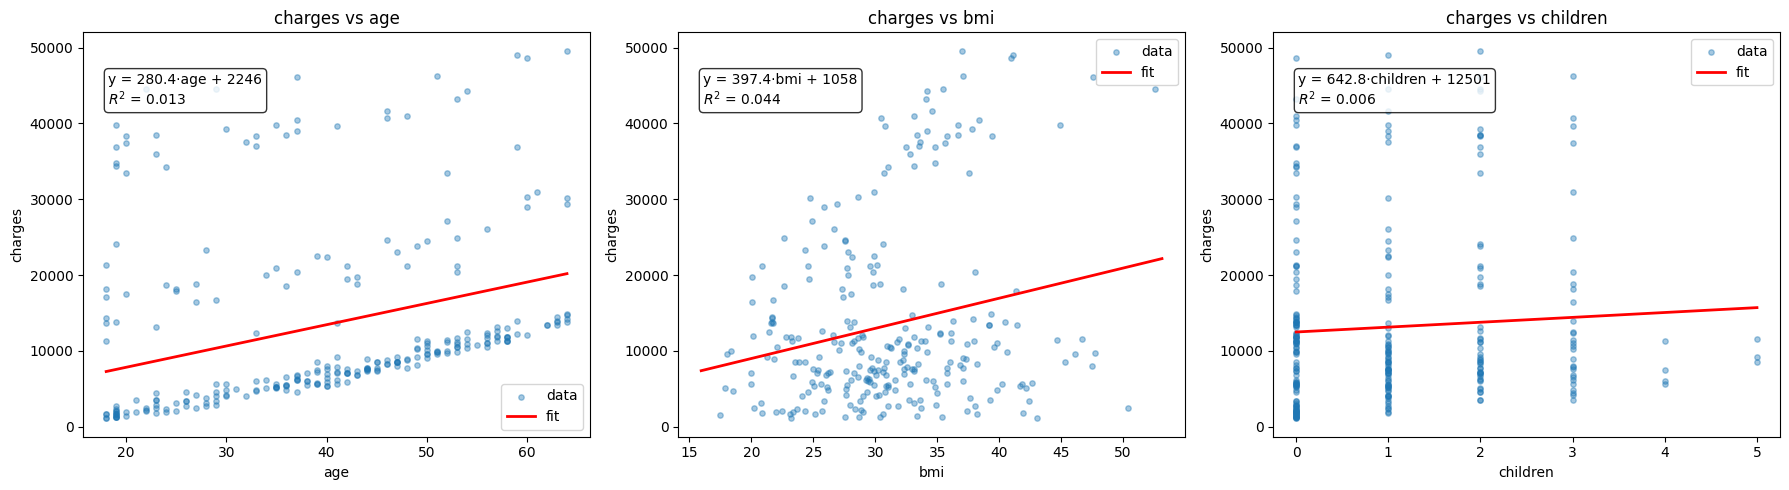

In [76]:
fig, axes = plt.subplots(1, len(numeric_features), figsize=(6 * len(numeric_features), 5))

for ax, col in zip(axes, numeric_features):
    pipe = pipes[col]
    scaler = pipe.named_steps['standardscaler']
    lr     = pipe.named_steps['linearregression']

    # unscale: y = b0 + b1*(x - mean)/std  ->  slope/intercept in original x units
    slope     = lr.coef_[0] / scaler.scale_[0]
    intercept = lr.intercept_ - lr.coef_[0] * scaler.mean_[0] / scaler.scale_[0]

    # data points (use full data or X_test — your choice)
    ax.scatter(X_test[col], y_test, alpha=0.4, s=15, label='data')

    # regression line over the x range
    x_line = np.linspace(X[col].min(), X[col].max(), 100)
    y_line = intercept + slope * x_line
    ax.plot(x_line, y_line, color='red', lw=2, label='fit')

    ax.set_title(f'charges vs {col}')
    ax.set_xlabel(col); ax.set_ylabel('charges')
    ax.annotate(f'y = {slope:.1f}·{col} + {intercept:.0f}\n$R^2$ = {results[col]["r2"]:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction',
                fontsize=10, va='top',
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    ax.legend()

plt.savefig('req1_numerical_plots.png')
plt.tight_layout()
plt.show()


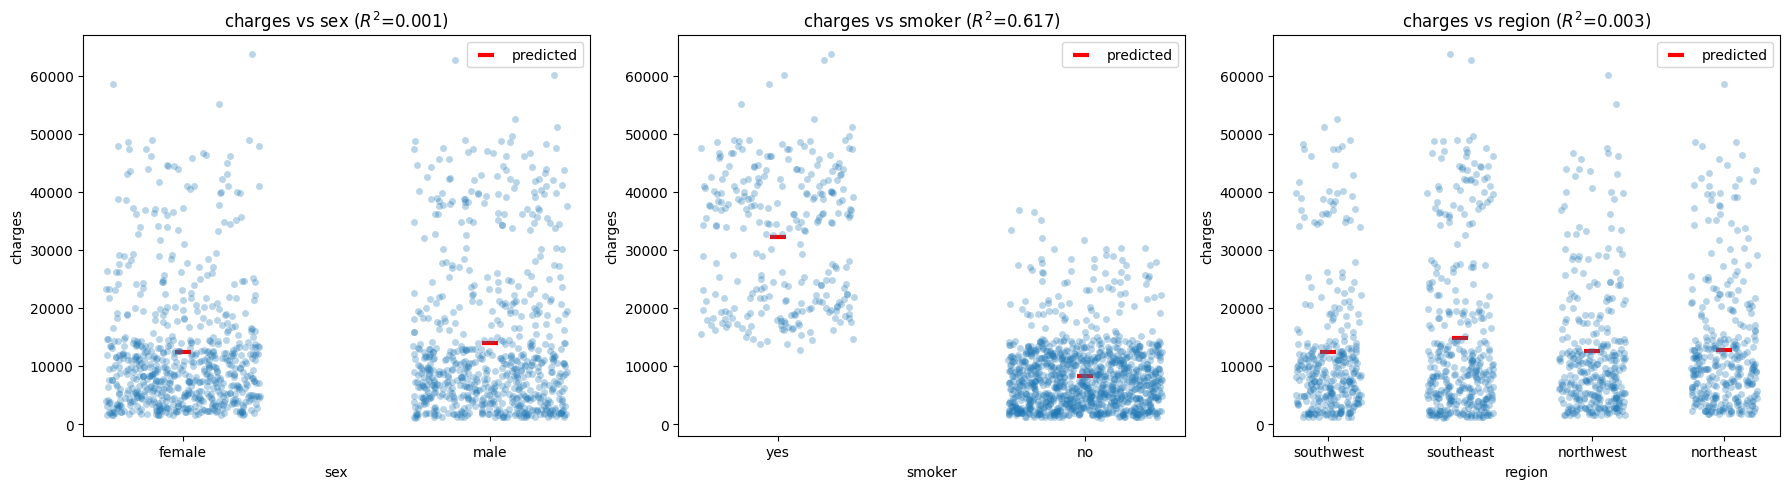

In [77]:
fig, axes = plt.subplots(1, len(categorical_features), figsize=(6 * len(categorical_features), 5))

for ax, col in zip(axes, categorical_features):
    pipe = pipes[col]
    seaborn.stripplot(x=df[col], y=df['charges'], ax=ax, alpha=0.3, jitter=0.25)

    # model prediction for each category
    cats = df[col].unique()
    preds = pipe.predict(pd.DataFrame({col: cats}))
    ax.scatter(range(len(cats)), preds, color='red', s=120, marker='_', lw=3, label='predicted')

    ax.set_title(f'charges vs {col} ($R^2$={results[col]["r2"]:.3f})')
    ax.legend()

plt.savefig('req1_categorical_plots.png')
plt.tight_layout()
plt.show()


## Requirement 2 "Predict the medical charges" (Regression) 
I need a tool that estimates how much a new customer will cost us per year, so we can price their premium 
fairly. 
Deliverable: Build, compare, and evaluate the following regression models to predict charges: 
### Model Notes 
1. Simple Linear Regression Use the single best predictor you found in EDA 
2. Multiple Linear Regression All features  
3. Polynomial Regression Try degrees 2–4; discuss overfitting 
4. Ridge Regression (L2) Tune alpha 
5. Lasso Regression (L1) Tune alpha; report which features it eliminated 
6. Support  Vector  Regression (SVR) Try at least two kernels; remember to scale features 
7. Decision Tree Regression Control max_depth; visualize the tree if possible 
 
Evaluation: Use a proper train/test split. Compare all models with MAE, MSE, RMSE, and R² in a single 
summary table, and recommend ONE model to the stakeholder with justification. 

In [78]:
req2_results = {}

In [79]:
# Simple Linear Regression using smoking status as feature
model1 = make_pipeline(
    OneHotEncoder(),
    LinearRegression()
)

model1.fit(X_train[['smoker']],y_train)
y1_pred = model1.predict(X_test[['smoker']])

req2_results['Single Linear Regression'] = {
    'r2': r2_score(y_test, y1_pred),
    'MAE': mean_absolute_error(y_test,y1_pred),
    'MSE': mean_squared_error(y_test, y1_pred),
    'RMSE': root_mean_squared_error(y_test,y1_pred)
}

In [80]:
preprocessor = ColumnTransformer(
    [('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features)]
)

model2 = make_pipeline(
    preprocessor,
    LinearRegression()
)

model2.fit(X_train, y_train)

y2_pred = model2.predict(X_test)

req2_results['Multiple Linear Regression'] = {
    'r2': r2_score(y_test, y2_pred),
    'MAE': mean_absolute_error(y_test, y2_pred),
    'MSE': mean_squared_error(y_test, y2_pred),
    'RMSE': root_mean_squared_error(y_test, y2_pred)
}

In [81]:
model3_2 = make_pipeline(
    preprocessor,
    PolynomialFeatures(degree=2),
    LinearRegression()
)

model3_2.fit(X_train,y_train)
y3_2_pred = model3_2.predict(X_test)

req2_results['Degree 2 Polynomial'] = {
    'r2': r2_score(y_test, y3_2_pred),
    'MAE': mean_absolute_error(y_test, y3_2_pred),
    'MSE': mean_squared_error(y_test, y3_2_pred),
    'RMSE': root_mean_squared_error(y_test, y3_2_pred)
}

In [82]:
model3_3 = make_pipeline(
    preprocessor,
    PolynomialFeatures(degree=3),
    LinearRegression()
)

model3_3.fit(X_train,y_train)
y3_3_pred = model3_3.predict(X_test)

req2_results['Degree 3 Polynomial'] = {
    'r2': r2_score(y_test, y3_3_pred),
    'MAE': mean_absolute_error(y_test, y3_3_pred),
    'MSE': mean_squared_error(y_test, y3_3_pred),
    'RMSE': root_mean_squared_error(y_test, y3_3_pred)    
}

In [83]:
model3_4 = make_pipeline(
    preprocessor,
    PolynomialFeatures(degree=4),
    LinearRegression()
)

model3_4.fit(X_train,y_train)
y3_4_pred = model3_4.predict(X_test)

req2_results['Degree 4 Polynomial'] = {
    'r2': r2_score(y_test, y3_4_pred),
    'MAE': mean_absolute_error(y_test, y3_4_pred),
    'MSE': mean_squared_error(y_test, y3_4_pred),
    'RMSE': root_mean_squared_error(y_test, y3_4_pred)
}

In [84]:
model4 = make_pipeline(
    preprocessor,
    RidgeCV(
        alphas=np.logspace(-3,3,100),
        store_cv_results=True
    )
)

model4.fit(X_train,y_train)
y4_pred = model4.predict(X_test)

req2_results['Ridge Regression'] = {
    'r2': r2_score(y_test, y4_pred),
    'MAE': mean_absolute_error(y_test, y4_pred),
    'MSE': mean_squared_error(y_test, y4_pred),
    'RMSE': root_mean_squared_error(y_test, y4_pred)
}

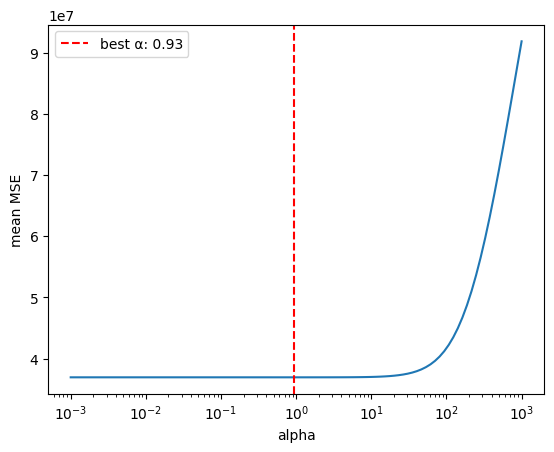

In [85]:
ridge = model4.named_steps['ridgecv']

plt.Figure()
plt.plot(ridge.alphas, ridge.cv_results_.mean(axis=0))
plt.axvline(ridge.alpha_, color="r", ls="--", label=f'best ⍺: {ridge.alpha_:.2f}')
plt.xscale("log")
plt.xlabel("alpha"); plt.ylabel("mean MSE"); plt.legend()
plt.show()

In [86]:
model5 = make_pipeline(
    preprocessor,
    LassoCV(
        cv=5, 
        max_iter=1000, 
        random_state=42)
)

model5.fit(X_train, y_train)
y5_pred = model5.predict(X_test)

req2_results['Lasso Regression'] = {
    'r2': r2_score(y_test, y5_pred),
    'MAE': mean_absolute_error(y_test, y5_pred),
    'MSE': mean_squared_error(y_test, y5_pred),
    'RMSE': root_mean_squared_error(y_test, y5_pred)
}

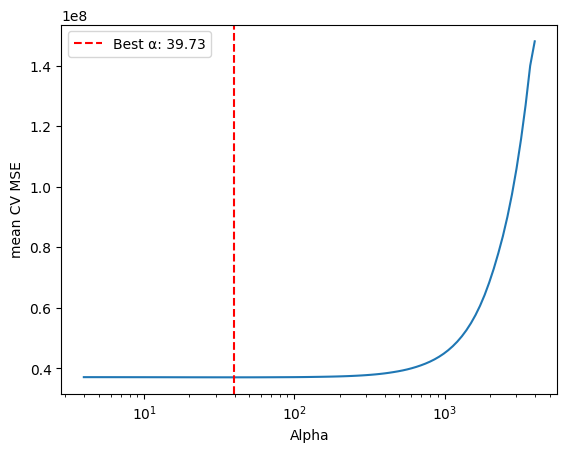

In [87]:
#View alphas
lasso = model5.named_steps['lassocv']

plt.Figure()
plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1))
plt.axvline(lasso.alpha_, color='r', ls='--',label=f'Best ⍺: {lasso.alpha_:.2f}')
plt.xscale('log')
plt.xlabel("Alpha"); plt.ylabel("mean CV MSE"); plt.legend()
plt.show()

In [88]:
names = model4[:-1].get_feature_names_out()
lasso_coefs = pd.Series(lasso.coef_, index=names)
print(lasso_coefs)

num__age                 3.669547e+03
num__bmi                 1.963603e+03
num__children            5.740693e+02
cat__sex_female          0.000000e+00
cat__sex_male           -0.000000e+00
cat__smoker_no          -2.359268e+04
cat__smoker_yes          2.934107e-12
cat__region_northeast    5.148400e+02
cat__region_northwest    5.060531e+01
cat__region_southeast   -0.000000e+00
cat__region_southwest   -3.112273e+02
dtype: float64


The removed features are both sex indicators, smoker_no, and southeast. These features are either unimpactful (sex) or highly colinear with another feature (smoker_yes->smoker_no, region_southeast-> other regions)

In [89]:
svr_lin_pipe = make_pipeline(
    preprocessor,
    LinearSVR(max_iter=10000, random_state=42)
)
model6_1 = TransformedTargetRegressor(
    regressor=svr_lin_pipe,
    transformer=StandardScaler()
)

param_grid_lin = {
    'regressor__linearsvr__C': [0.1, 1, 10, 100],
    'regressor__linearsvr__epsilon': [0.0, 0.01, 0.1, 0.5],
}

search6_1 = GridSearchCV(model6_1, param_grid_lin, cv=5, scoring='r2', n_jobs=-1)
search6_1.fit(X_train, y_train)
y6_1_pred = search6_1.predict(X_test)
print('SVR Linear best params:', search6_1.best_params_)


SVR Linear best params: {'regressor__linearsvr__C': 10, 'regressor__linearsvr__epsilon': 0.5}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [90]:
# SVR (RBF kernel): scale the target and tune C / epsilon / gamma with GridSearchCV.
# RBF must use libsvm (no fast linear solver exists), so we cap C, enlarge the
# kernel cache, and keep the grid small to stay fast.
svr_rbf_pipe = make_pipeline(
    preprocessor,
    SVR(kernel='rbf', cache_size=1000)
)
model6_2 = TransformedTargetRegressor(
    regressor=svr_rbf_pipe,
    transformer=StandardScaler()
)

param_grid_rbf = {
    'regressor__svr__C': [1, 10, 100],
    'regressor__svr__epsilon': [0.01, 0.1, 0.5],
    'regressor__svr__gamma': ['scale', 0.1],
}

search6_2 = GridSearchCV(model6_2, param_grid_rbf, cv=5, scoring='r2', n_jobs=-1)
search6_2.fit(X_train, y_train)
y6_2_pred = search6_2.predict(X_test)
print('SVR RBF best params:', search6_2.best_params_)

req2_results['SVR RBF'] = {
    'r2': r2_score(y_test, y6_2_pred),
    'MAE': mean_absolute_error(y_test, y6_2_pred),
    'MSE': mean_squared_error(y_test, y6_2_pred),
    'RMSE': root_mean_squared_error(y_test, y6_2_pred)
}

SVR RBF best params: {'regressor__svr__C': 1, 'regressor__svr__epsilon': 0.1, 'regressor__svr__gamma': 0.1}


In [91]:
model7 = make_pipeline(
    preprocessor,
    DecisionTreeRegressor(
        max_depth=5
    )
)

model7.fit(X_train,y_train)
y7_pred = model7.predict(X_test)

req2_results['Decision Tree Regression'] = {
    'r2': r2_score(y_test, y7_pred),
    'MAE': mean_absolute_error(y_test, y7_pred),
    'MSE': mean_squared_error(y_test, y7_pred),
    'RMSE': root_mean_squared_error(y_test, y7_pred)
}

In [94]:
req2_results_df = pd.DataFrame(req2_results).T

req2_results_df.sort_values(['r2'], ascending=False)

,r2,MAE,MSE,RMSE
Decision Tree Regression,0.853226,2547.724194,2.042274e+07,4519.152402
SVR RBF,0.842011,2523.123928,2.198318e+07,4688.622823
Degree 2 Polynomial,0.836526,2816.053746,2.274647e+07,4769.325455
Degree 3 Polynomial,0.829719,2974.072542,2.369361e+07,4867.608615
Ridge Regression,0.729784,4410.967276,3.759900e+07,6131.802222
Multiple Linear Regression,0.729753,4406.793913,3.760328e+07,6132.151642
Lasso Regression,0.729625,4412.744783,3.762115e+07,6133.607977
Degree 4 Polynomial,0.692798,3724.651788,4.274538e+07,6537.995253
Single Linear Regression,0.617377,5395.152670,5.323979e+07,7296.560128


## Requirement 3 "Flag the expensive customers" (Classification) 
Honestly, I don't always need the exact dollar amount. Sometimes I just need to know: is this customer going to 
be expensive or not? Our finance team defines 'expensive' as anyone whose annual charges exceed the media. <- assuming this means median

In [108]:
median_charge = y.median()

y_classification = (y > median_charge).astype(int)

y_classification_train, y_classification_test = train_test_split(y_classification, test_size=0.2, random_state=14)

In [117]:
model_expensive = make_pipeline(
    preprocessor,
    DecisionTreeClassifier()
)

model_expensive.fit(X_train,y_classification_train)
y_expensive_pred = model_expensive.predict(X_test)

req3_results = {}
req3_results['Expensive Decision Tree'] = {
    'accuracy': accuracy_score(y_classification_test, y_expensive_pred),
    'precision': precision_score(y_classification_test, y_expensive_pred),
    'recall': recall_score(y_classification_test,y_expensive_pred),
    'f1': f1_score(y_classification_test, y_expensive_pred)
}

In [118]:
req3_results_df = pd.DataFrame(req3_results).T

req3_results_df

,accuracy,precision,recall,f1
Expensive Decision Tree,0.88806,0.889706,0.889706,0.889706


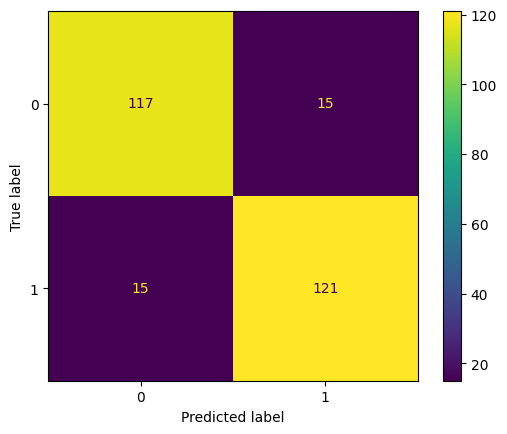

In [119]:
ConfusionMatrixDisplay.from_estimator(model_expensive, X_test, y_classification_test)